# Experiment 2 - Block-Size Sweep: Where Is the Optimal Page Size?

**Research question (Exp 2):** A paged KV cache stores attention state in fixed-size blocks. The block
size sets up a *crossover* between two opposing costs:

- **larger blocks -> cheaper reads** (fewer pages to gather per decode step), but
- **larger blocks -> more internal fragmentation** (the last block of every sequence is partly empty,
  wasting ~`block_size / 2` slots) and, if attention runs over whole blocks, more wasted compute.

Where these two forces cross is the optimal `block_size`. This sweep (block_size 8/16/32/64, paged
only, FP16) measures it directly. It is the *novel* part of the study: the vLLM paper fixed the page
size; here it is the independent variable.

**Hypothesis H2 (small optimum).** Fragmentation dominates the lookup saving, so (a) absolute wasted
memory grows ~linearly with `block_size`, and (b) sustained throughput peaks at a *small* block
(<= 16) and falls for 32/64. Falsifier: throughput flat or rising in `block_size`, or wasted memory
independent of `block_size`.

This notebook reports, in order:
1. **Fragmentation** - the clean structural signal (Figure 2).
2. **Throughput optimum** - does the structural cost show up in tokens/sec? (the headline)
3. **Decode latency (TPOT)** - where large blocks break the launch-bound flat regime.
4. **Memory footprint** - the coarser-boundary tax.
5. **Synthesis** - the recommended block size.

> Methodology: medians over 20 measured runs after 3 warm-ups, CUDA, FP16 pages. `seq_len`s are
> deliberately *non-multiples* of the block sizes so fragmentation actually varies. Decode on this GPU
> is partly launch-bound (Exp 1), so fragmentation/memory are the guaranteed-clean signals; the
> throughput effect reported here is large enough (~2x across blocks) to clear that noise floor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- locate experiments/results no matter where the kernel started ---
def find_results_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / 'experiments' / 'results'
        if cand.exists():
            return cand
    raise FileNotFoundError('Could not find experiments/results from ' + str(Path.cwd()))

RESULTS = find_results_dir()
CSV = RESULTS / 'exp2_block_size_sweep.csv'
print('Loading:', CSV.name)

df = pd.read_csv(CSV)

# OOM / slow are first-class outcomes: keep them flagged, drop from timing views.
df['ok'] = df['status'].astype(str).str.lower().eq('ok')
NUM = ['ttft_ms', 'tpot_ms', 'throughput', 'throughput_cv',
       'peak_memory_mb', 'cache_memory_mb', 'frag_ratio']
for c in NUM:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Derived: frag_ratio is the *fraction of the last block left unused*, so the
# absolute waste in slots = frag_ratio * block_size. That is the quantity that
# actually scales with block_size (the ratio alone hides it).
df['wasted_slots'] = df['frag_ratio'] * df['block_size']

ok = df[df['ok']].copy()
BLOCKS = sorted(df.block_size.unique())
print(f'{len(df)} rows | {(~df.ok).sum()} non-ok (oom/slow) | block_size: {BLOCKS}')
print(f'seq_len: {sorted(ok.seq_len.unique())}  batch: {sorted(ok.batch.unique())}')
df.head()

Loading: exp2_block_size_sweep.csv
60 rows | 0 non-ok (oom/slow) | block_size: [np.int64(8), np.int64(16), np.int64(32), np.int64(64)]
seq_len: [np.int64(100), np.int64(300), np.int64(600), np.int64(1100), np.int64(2000)]  batch: [np.int64(1), np.int64(8), np.int64(16)]


,cache_type,seq_len,batch,block_size,status,ttft_ms,tpot_ms,throughput,throughput_cv,peak_memory_mb,cache_memory_mb,frag_ratio,ok,wasted_slots
0,paged,100,1,8,ok,13.905,7.465,123.4,16.12,169.02,2.50,0.0,True,0.0
1,paged,100,8,8,ok,43.235,15.609,460.3,20.78,257.67,20.00,0.0,True,0.0
2,paged,100,16,8,ok,75.622,32.257,448.1,15.62,358.43,40.00,0.0,True,0.0
3,paged,300,1,8,ok,17.595,6.113,140.7,15.06,192.24,5.62,0.0,True,0.0
4,paged,300,8,8,ok,101.677,18.304,366.3,15.78,442.25,45.00,0.0,True,0.0


## 1. Fragmentation - the structural signal

`frag_ratio` in the CSV is the fraction of each sequence's *last* block that sits unused. As a ratio
it stays bounded and looks mild, but the quantity that costs memory is the **absolute** waste,
`frag_ratio * block_size` slots per sequence - and that grows with the block size.

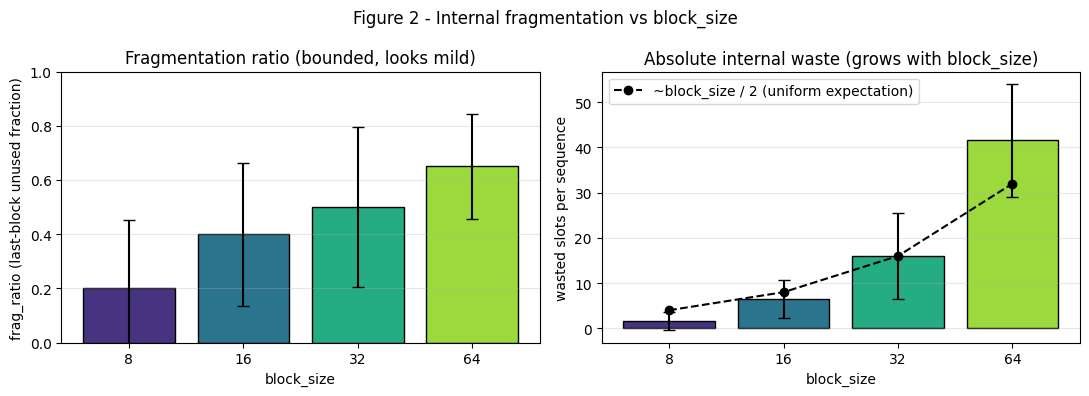

Mean wasted slots / sequence by block_size:
  block  8: 1.6 slots  (frag_ratio 0.20)
  block 16: 6.4 slots  (frag_ratio 0.40)
  block 32: 16.0 slots  (frag_ratio 0.50)
  block 64: 41.6 slots  (frag_ratio 0.65)


In [2]:
# Figure 2 - the structural signal. frag_ratio is bounded in [0, 1) and noisy,
# but ABSOLUTE wasted slots (= frag_ratio * block_size) is what costs memory,
# and it grows roughly linearly with block_size.
BLOCK_COLOR = plt.cm.viridis(np.linspace(0.15, 0.85, len(BLOCKS)))

frag_by_block = ok.groupby('block_size')['frag_ratio'].agg(['mean', 'std'])
waste_by_block = ok.groupby('block_size')['wasted_slots'].agg(['mean', 'std'])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))

a1.bar([str(b) for b in frag_by_block.index], frag_by_block['mean'],
       yerr=frag_by_block['std'], capsize=4, color=BLOCK_COLOR, edgecolor='black')
a1.set(xlabel='block_size', ylabel='frag_ratio (last-block unused fraction)',
       title='Fragmentation ratio (bounded, looks mild)')
a1.set_ylim(0, 1); a1.grid(True, axis='y', alpha=0.3)

a2.bar([str(b) for b in waste_by_block.index], waste_by_block['mean'],
       yerr=waste_by_block['std'], capsize=4, color=BLOCK_COLOR, edgecolor='black')
# reference: expected waste for uniformly random seq_len is ~block_size / 2
a2.plot(range(len(BLOCKS)), [b / 2 for b in BLOCKS], 'k--', marker='o',
        label='~block_size / 2 (uniform expectation)')
a2.set(xlabel='block_size', ylabel='wasted slots per sequence',
       title='Absolute internal waste (grows with block_size)')
a2.legend(); a2.grid(True, axis='y', alpha=0.3)
fig.suptitle('Figure 2 - Internal fragmentation vs block_size')
fig.tight_layout(); plt.show()

print('Mean wasted slots / sequence by block_size:')
for b in BLOCKS:
    print(f'  block {b:>2}: {waste_by_block.loc[b, "mean"]:.1f} slots'
          f'  (frag_ratio {frag_by_block.loc[b, "mean"]:.2f})')

## 2. Throughput optimum - the headline

For every `(seq_len, batch)` cell we normalise throughput to that cell's *best* block_size, then
average. This strips out the seq/batch scaling and leaves the pure `block_size` effect: if H2 holds
the curve peaks at a small block and drops toward 64. The right panel shows which block wins each
regime - the practitioner's lookup table.

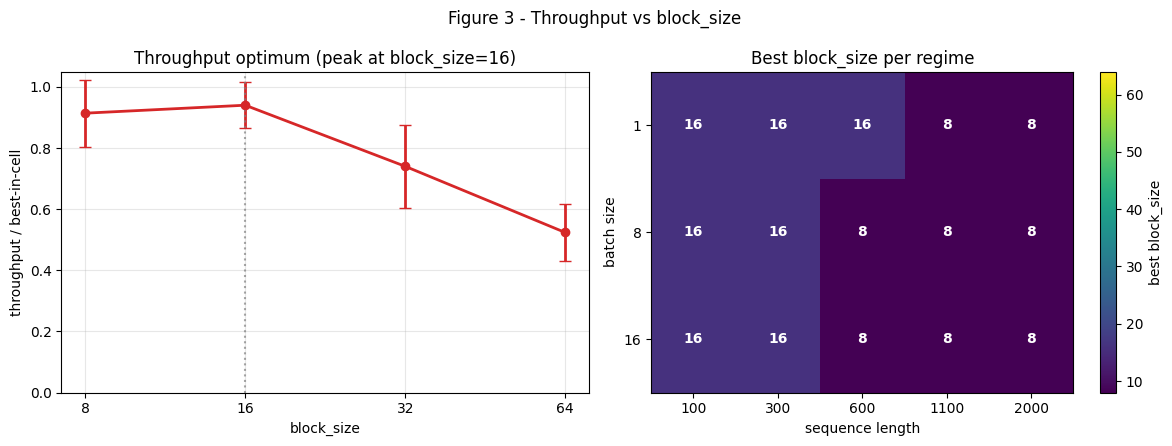

Mean normalised throughput by block_size (1.00 = best):
  block  8: 0.914
  block 16: 0.940
  block 32: 0.740
  block 64: 0.524

Large-block penalty: block 64 runs at 52% of the per-cell best, block 16 at 94%.


In [3]:
# Isolate the block_size effect: within each (seq_len, batch) cell, normalise
# throughput to that cell's best block_size, then average across cells.
piv = ok.pivot_table(index=['seq_len', 'batch'], columns='block_size', values='throughput')
norm = piv.div(piv.max(axis=1), axis=0)          # 1.0 == best block for that cell
norm_mean, norm_std = norm.mean(), norm.std()
best_block = int(norm_mean.idxmax())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))

# (left) normalised throughput vs block_size - the optimum curve
a1.errorbar([str(b) for b in norm_mean.index], norm_mean.values, yerr=norm_std.values,
            marker='o', capsize=4, color='#d62728', linewidth=2)
a1.axvline(list(norm_mean.index).index(best_block), color='gray', ls=':', alpha=0.7)
a1.set(xlabel='block_size', ylabel='throughput / best-in-cell',
       title=f'Throughput optimum (peak at block_size={best_block})')
a1.set_ylim(0, 1.05); a1.grid(True, alpha=0.3)

# (right) which block_size wins each (seq_len, batch) cell
argmax = piv.idxmax(axis=1).rename('best_block').reset_index()
heat = argmax.pivot(index='batch', columns='seq_len', values='best_block').sort_index()
im = a2.imshow(heat.values, cmap='viridis', aspect='auto',
               vmin=min(BLOCKS), vmax=max(BLOCKS))
a2.set_xticks(range(len(heat.columns)), heat.columns)
a2.set_yticks(range(len(heat.index)), heat.index)
a2.set(xlabel='sequence length', ylabel='batch size', title='Best block_size per regime')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if not np.isnan(v):
            a2.text(j, i, int(v), ha='center', va='center', color='white', fontweight='bold')
fig.colorbar(im, ax=a2, label='best block_size')
fig.suptitle('Figure 3 - Throughput vs block_size')
fig.tight_layout(); plt.show()

print('Mean normalised throughput by block_size (1.00 = best):')
for b in norm_mean.index:
    print(f'  block {int(b):>2}: {norm_mean[b]:.3f}')
print(f'\nLarge-block penalty: block {max(BLOCKS)} runs at '
      f'{norm_mean[max(BLOCKS)] * 100:.0f}% of the per-cell best, '
      f'block {best_block} at {norm_mean[best_block] * 100:.0f}%.')

## 3. Decode latency (TPOT) - where flatness breaks

Exp 1 showed decode here is largely **launch-bound**: TPOT stays roughly flat and run-to-run CV is
~10-20%. The block-size sweep tests whether that holds across page sizes. The mechanism to watch:
paged attention reads *whole* blocks, so a larger block makes every decode step touch more
padded/unused slots - turning fragmentation into wasted compute.

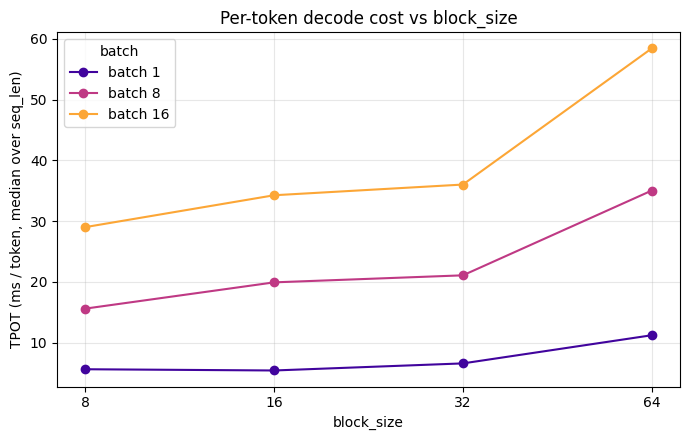

TPOT growth from smallest to largest block_size, per batch:
  batch  1: 5.6 -> 11.2 ms  (1.99x)
  batch  8: 15.6 -> 35.0 ms  (2.24x)
  batch 16: 29.0 -> 58.4 ms  (2.01x)


In [4]:
# Decode cost vs block_size: small blocks stay flat (launch-bound); large
# blocks add real per-token cost as attention runs over more padded slots.
tpot_by = ok.groupby(['batch', 'block_size'])['tpot_ms'].median().unstack('block_size')

fig, ax = plt.subplots(figsize=(7, 4.5))
for batch, color in zip(tpot_by.index, plt.cm.plasma(np.linspace(0.1, 0.8, len(tpot_by.index)))):
    ax.plot([str(b) for b in tpot_by.columns], tpot_by.loc[batch].values,
            marker='o', label=f'batch {batch}', color=color)
ax.set(xlabel='block_size', ylabel='TPOT (ms / token, median over seq_len)',
       title='Per-token decode cost vs block_size')
ax.grid(True, alpha=0.3); ax.legend(title='batch')
fig.tight_layout(); plt.show()

print('TPOT growth from smallest to largest block_size, per batch:')
for batch in tpot_by.index:
    row = tpot_by.loc[batch]
    print(f'  batch {int(batch):>2}: {row.iloc[0]:.1f} -> {row.iloc[-1]:.1f} ms'
          f'  ({row.iloc[-1] / row.iloc[0]:.2f}x)')

## 4. Memory footprint - the coarser-boundary tax

Each sequence's cache is rounded up to a whole number of blocks, so a bigger block reserves more
slack for the same workload. The effect is small relative to model + activation memory, but it is
strictly in the *wrong* direction for large blocks.

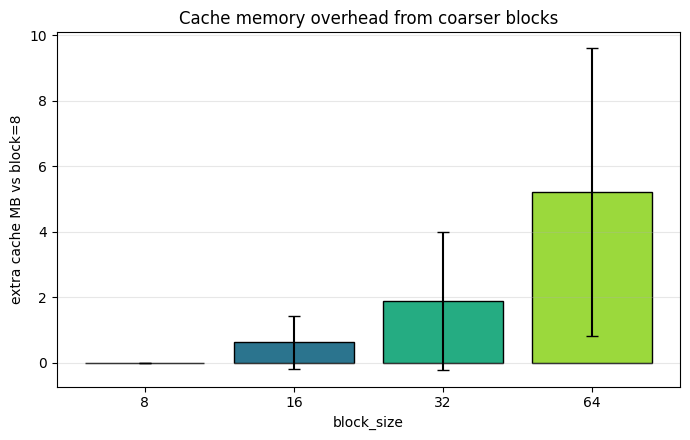

Mean cache memory (MB) by block_size:
  block  8: 114.8 MB  (+0.0 vs block 8)
  block 16: 115.4 MB  (+0.6 vs block 8)
  block 32: 116.7 MB  (+1.9 vs block 8)
  block 64: 120.0 MB  (+5.2 vs block 8)


In [5]:
# Cache memory grows slightly with block_size (coarser rounding per sequence).
mem_by = ok.pivot_table(index=['seq_len', 'batch'], columns='block_size', values='cache_memory_mb')
delta = mem_by.sub(mem_by[min(BLOCKS)], axis=0)   # extra MB vs the smallest block

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar([str(b) for b in delta.columns], delta.mean().values,
       yerr=delta.std().values, capsize=4, color=BLOCK_COLOR, edgecolor='black')
ax.set(xlabel='block_size', ylabel=f'extra cache MB vs block={min(BLOCKS)}',
       title='Cache memory overhead from coarser blocks')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout(); plt.show()

print('Mean cache memory (MB) by block_size:')
for b in BLOCKS:
    print(f'  block {b:>2}: {mem_by[b].mean():.1f} MB  (+{delta[b].mean():.1f} vs block {min(BLOCKS)})')

## 5. Synthesis

The cell below reads the numbers back out of the loaded CSV so the written verdict always matches the
data.

In [ ]:
print(f'Source: {CSV.name}\n' + '=' * 66)

# 1. Fragmentation grows with block_size (absolute slots)
w_small, w_big = waste_by_block.loc[min(BLOCKS), 'mean'], waste_by_block.loc[max(BLOCKS), 'mean']
print(f'1. Fragmentation: wasted slots/seq grow {w_small:.1f} -> {w_big:.1f} '
      f'({w_big / max(w_small, 1e-9):.1f}x) from block {min(BLOCKS)} to {max(BLOCKS)} - '
      f'internal waste scales ~linearly with block_size.')

# 2. Throughput optimum
print(f'2. Throughput optimum: block_size={best_block} is fastest; block {max(BLOCKS)} '
      f'sustains only {norm_mean[max(BLOCKS)] * 100:.0f}% of the per-cell best. Small blocks win.')

# 3. Decode cost
small_tpot = tpot_by[min(BLOCKS)].mean()
big_tpot = tpot_by[max(BLOCKS)].mean()
print(f'3. Decode cost: TPOT ~flat for small blocks ({small_tpot:.0f} ms) but rises to '
      f'{big_tpot:.0f} ms at block {max(BLOCKS)} - large blocks waste per-token compute on padding.')

# 4. H2 verdict
h2 = (best_block <= 16) and (norm_mean[max(BLOCKS)] < norm_mean[best_block]) and (w_big > w_small)
print(f'4. H2 (small optimum; fragmentation + throughput both favour small blocks): '
      f'{"SUPPORTED" if h2 else "NOT SUPPORTED"}.')
print('   Recommendation: default block_size 8-16. 32/64 lose on fragmentation, memory, AND'
      ' throughput - no regime in this sweep rewards them.')
print('=' * 66)

Source: exp2_block_size_sweep.csv
1. Fragmentation: wasted slots/seq grow 1.6 -> 41.6 (26.0x) from block 8 to 64 - internal waste scales ~linearly with block_size.
2. Throughput optimum: block_size=16 is fastest; block 64 sustains only 52% of the per-cell best. Small blocks win.
3. Decode cost: TPOT ~flat for small blocks (17 ms) but rises to 35 ms at block 64 - large blocks waste per-token compute on padding.
4. H2 (small optimum; fragmentation + throughput both favour small blocks): SUPPORTED.
   Recommendation: default block_size 8-16. 32/64 lose on fragmentation, memory, AND throughput - no regime in this sweep rewards them.


: 